In [60]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time
from datetime import datetime
# today = int(datetime.today().strftime('%Y%m%d'))
today = datetime.today().strftime('%Y_%m_%d')
from skimage.registration import phase_cross_correlation
import copy
from importlib import reload
from IPython.display import clear_output, display
from pathlib import Path
import os
cwd = Path(os.getcwd())

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle

import magpyx
from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, rt_utils, coro_utils

import fsm_utils
import cam_utils

v_bias = np.array([[50, 50, 50]]).T
zeros = np.array([[0, 0, 0]]).T
vals = np.array([[1, 0, 0]]).T

wavelength = 633e-9
fl = 500e-3
fsm_pupil_diam = 6.7e-3
rad_per_lamD = wavelength/fsm_pupil_diam
print(rad_per_lamD)
as_per_lamD = (wavelength/fsm_pupil_diam*u.radian).to_value(u.arcsec)
print(as_per_lamD)

pxscl_lamD = 3.45e-6 / (fl * wavelength/fsm_pupil_diam)
print(pxscl_lamD)

INFO:purepyindi2.transports:Opening localhost:7624...


9.44776119402985e-05
19.48740632155403
0.07303317535545024


INFO:purepyindi2.transports:Connected to localhost:7624


In [61]:
camfsm_channel = 'camfsm'
dmt_channel = 'dm00disp'
dm0_channel = 'dm00disp00'
dm1_channel = 'dm00disp01'

CAMFSM_STREAM = ImageStream(camfsm_channel)
DMT_STREAM = ImageStream(dmt_channel)
DM0_STREAM = ImageStream(dm0_channel)
DM1_STREAM = ImageStream(dm1_channel)



# Setup camera ROI.

In [65]:
reload(cam_utils)
cam = cam_utils.CAM(camfsm_channel)

cam.get_roi_center(client0)


(955.5, 623.5)

In [133]:
npsf = 256//2
npsf = 40
cam.set_roi(980, 640, npsf, client0)
# cam.set_roi(995, 568, npsf, client0)

cam.set_exptime(0.0001, client0)

# Power on and bias FSM

In [66]:
reload(fsm_utils)
fsm_utils.power_fsm('On', client0)

In [67]:
DM0_STREAM.write(v_bias)

# Better center ROI

INFO:utils:Got semaphore index 1.


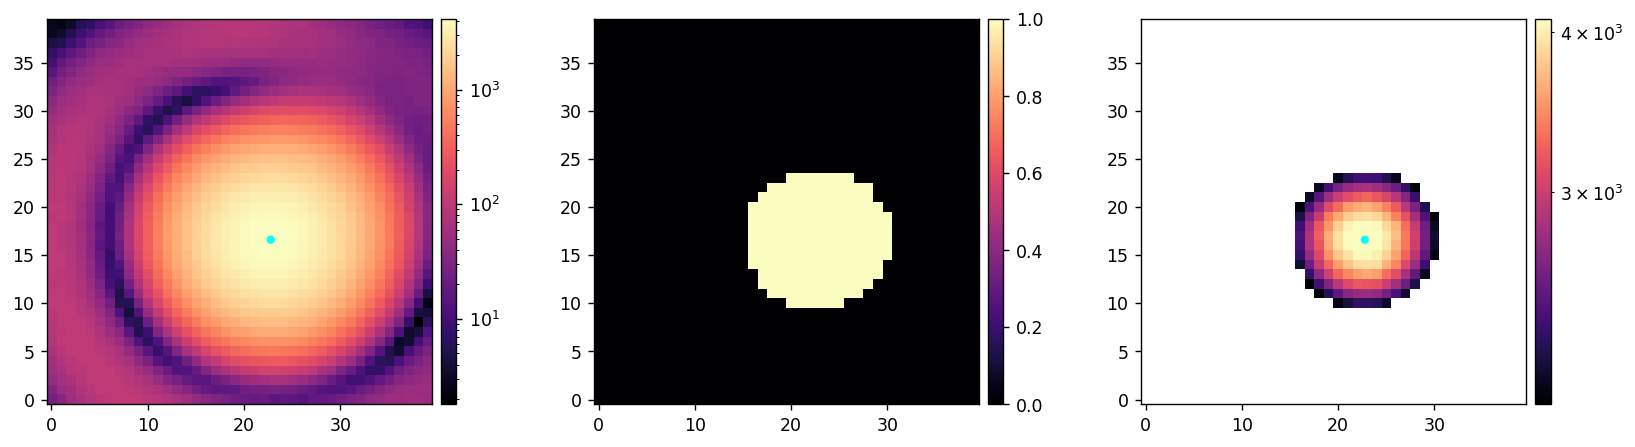

[22.78139542 16.60614822] [ 2.78139542 -3.39385178]


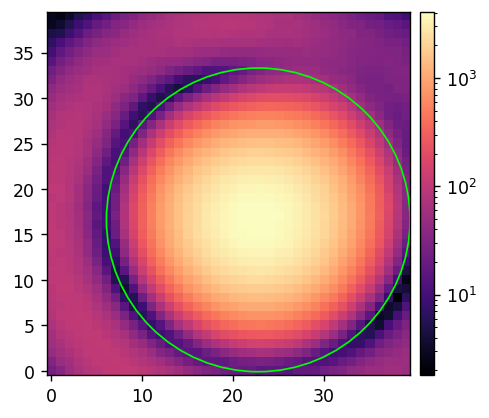

In [134]:
reload(utils)

cam.Nframes = 200
im = cam.snap()

cen = utils.centroid(
    im,
    thresh=0.5*im.max(),
)
shift = cen - npsf//2
print(cen, shift)
utils.imshow(
    [im], 
    norms=[LogNorm()],
    all_patches=[[Circle(cen, 1.22/pxscl_lamD, fill=False, color='lime')]],
)

In [135]:
# cam.set_roi(948, 625, npsf, client0)
xc, yc = cam.get_roi_center(client0)
cam.set_roi(xc+shift[0], yc+shift[1], npsf, client0)

# Test a step response while recording camera and actuator telemetry. 

In [188]:
reload(utils)
telem_path = Path(f'/opt/MagAOX/rawimages/')
data_path = Path(f'pzt3-poke-data-{today}')

camfsm_telem_path = telem_path/camfsm_channel/camfsm_channel/today
dmt_telem_path = telem_path/dmt_channel/dmt_channel/today
dm1_telem_path = telem_path/dm1_channel/dm1_channel/today

camfsm_data_path = data_path/camfsm_channel
dmt_data_path = data_path/dmt_channel
dm1_data_path = data_path/dm1_channel

utils.make_dir(dmt_data_path)
utils.make_dir(dm1_data_path)
utils.make_dir(camfsm_data_path)


In [ ]:
camfsm_data_path

PosixPath('pzt2-poke-data-2026_10_01/camfsm')

In [199]:
utils.delete_files(dmt_data_path/'*')
utils.delete_files(dm1_data_path/'*')
utils.delete_files(camfsm_data_path/'*')

In [173]:
act_pokes = np.moveaxis(np.array([np.eye(3)]), 0, -1)
act_pokes.shape, act_pokes[2].shape, zeros.shape, act_pokes[2]

((3, 3, 1),
 (3, 1),
 (3, 1),
 array([[0.],
        [0.],
        [1.]]))

In [190]:
DM1_STREAM.write(act_pokes[2])

In [193]:
DM1_STREAM.write(zeros)

In [200]:
reload(rt_utils)

rt_utils.toggle_telem(1, camfsm_channel, client0)
rt_utils.toggle_telem(1, dmt_channel, client0)
rt_utils.toggle_telem(1, dm1_channel, client0)

# time.sleep(2)
# for i in range(5):
#     DM1_STREAM.write(zeros)
#     time.sleep(0.5)

time.sleep(0.5)
# DM1_STREAM.write(act_pokes[0])
# DM1_STREAM.write(act_pokes[1])
DM1_STREAM.write(act_pokes[2])
time.sleep(0.5)

rt_utils.toggle_telem(0, camfsm_channel, client0)
rt_utils.toggle_telem(0, dmt_channel, client0)
rt_utils.toggle_telem(0, dm1_channel, client0)

In [209]:
DM1_STREAM.write(zeros)

In [201]:
reload(rt_utils)

rt_utils.unpack_data(
    camfsm_telem_path,
    camfsm_data_path,
)
rt_utils.unpack_data(
    dm1_telem_path,
    dm1_data_path,
)
rt_utils.unpack_data(
    dmt_telem_path,
    dmt_data_path,
)

In [202]:
# fnames = utils.get_fnames(dm01_telem_path/'fits/*.fits')
dmt_fnames = utils.get_fnames(dmt_data_path/'*.fits')
dm1_fnames = utils.get_fnames(dm1_data_path/'*.fits')
camfsm_fnames = utils.get_fnames(camfsm_data_path/'*.fits')

In [203]:
utils.delete_files(dmt_telem_path/'*.xrif')
utils.delete_files(dm1_telem_path/'*.xrif')
utils.delete_files(camfsm_telem_path/'*.xrif')

In [204]:
reload(rt_utils)
dmt_data, dmt_times = rt_utils.read_telem_data(dmt_fnames, rel_times=0)
dm1_data, dm1_times = rt_utils.read_telem_data(dm1_fnames, rel_times=0)
camfsm_data, camfsm_times = rt_utils.read_telem_data(camfsm_fnames, rel_times=0)
print(dmt_times, dm1_times, camfsm_times[0])

[84664.84599347] [84664.84602731] 84664.448067847


In [205]:
start = camfsm_times[0]
camfsm_times -= start
dmt_times -= start
dm1_times -= start
print(dmt_times, dm1_times, camfsm_times[0])

[0.39792563] [0.39795947] 0.0


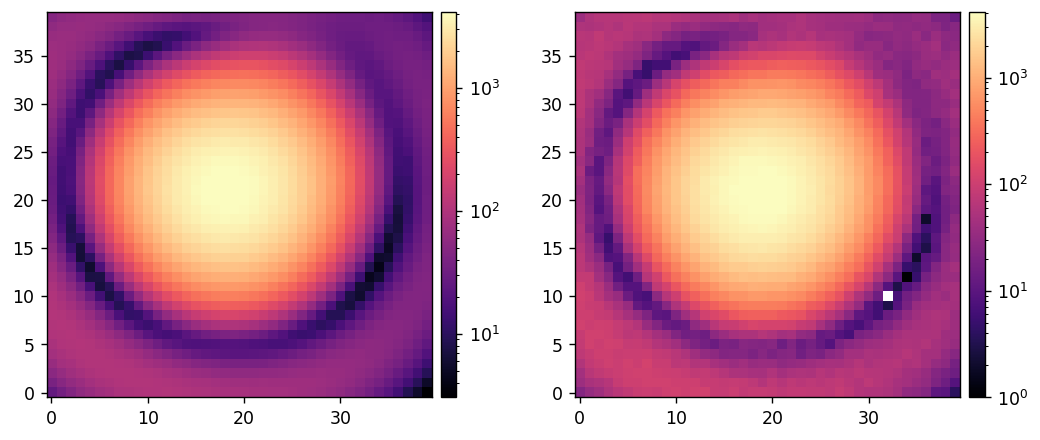

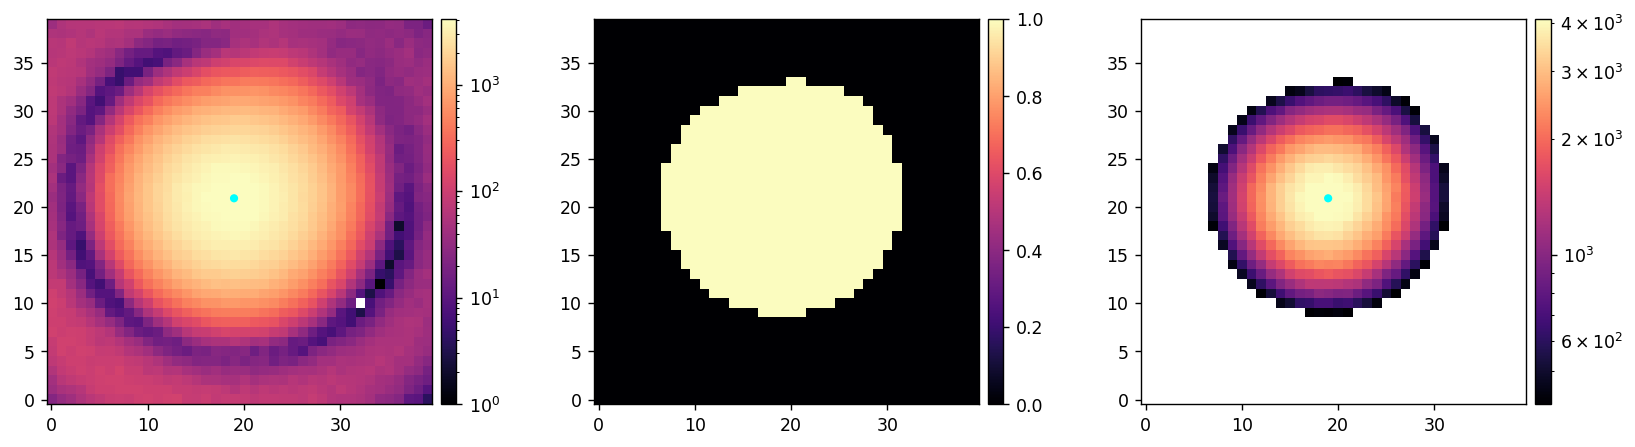

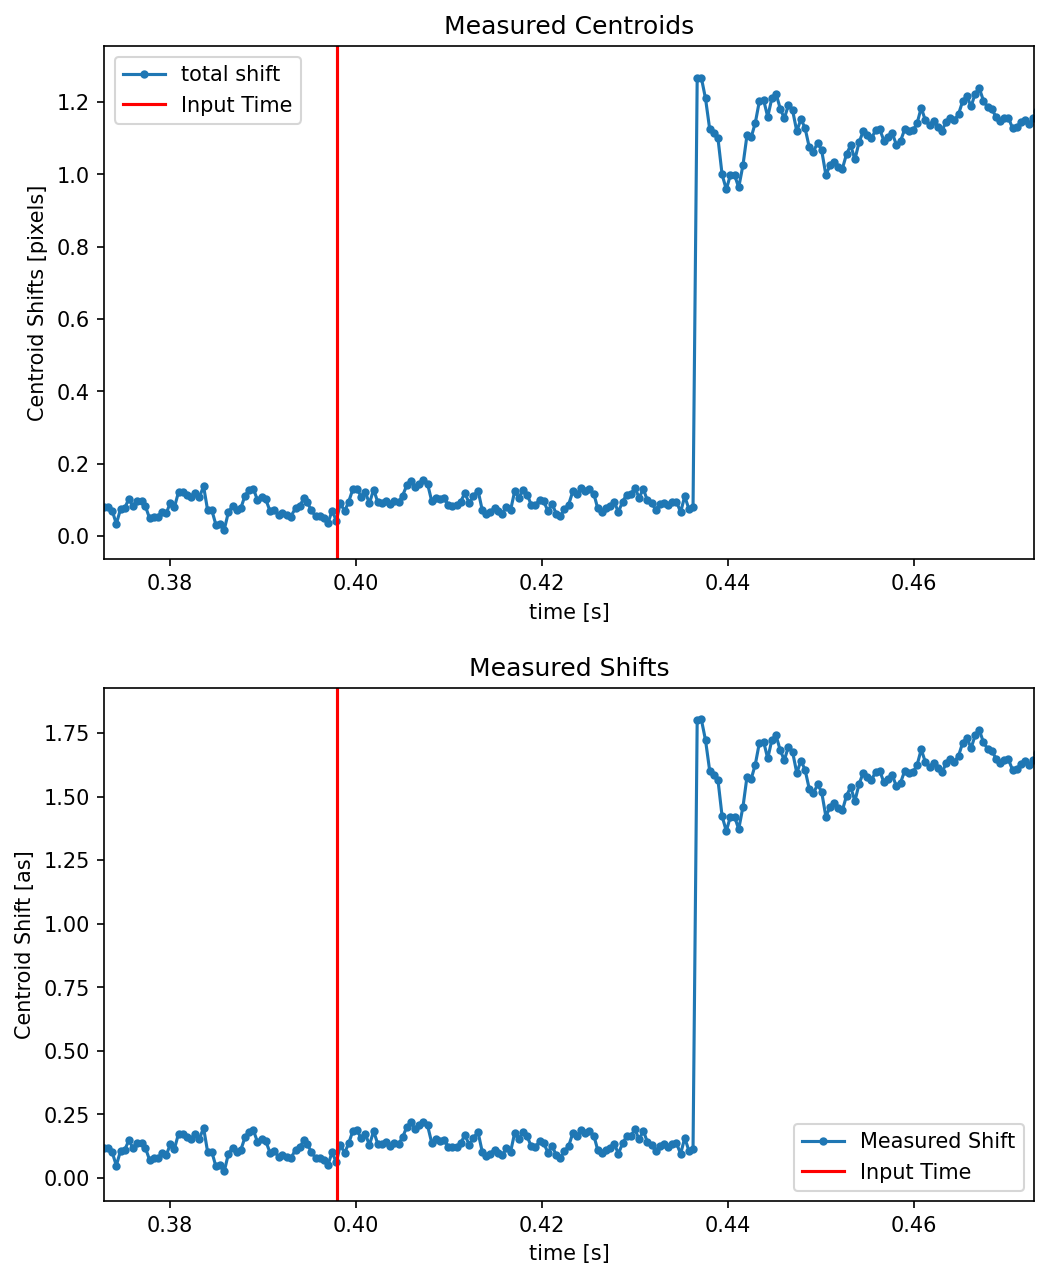

In [207]:
rel_thresh = 0.1

# ims = data['IMAGES']
ims = camfsm_data
N = ims.shape[0]
fps = cam.get_fps(client0)
times = camfsm_times
tmax = times.max()

mean_frame = np.mean(ims, axis=0)
utils.imshow([mean_frame, ims[0]], norms=[LogNorm(), LogNorm()])

shift_pix = []
cen_0 = utils.centroid(ims[0].astype(float), thresh=rel_thresh*ims[0].max(), plot=True)
for i in range(N):
    cen = utils.centroid(ims[i].astype(float), thresh=rel_thresh*ims[i].max(), plot=0)
    shift = cen - cen_0
    shift_pix.append(shift)
shift_pix = np.array(shift_pix)

total_shift = np.sqrt( np.sum( np.square(shift_pix), axis=1) )

shift_as = shift_pix * pxscl_lamD * as_per_lamD # pixels * (lamD/pixel) * (as/lamD)
shift_as = np.sqrt( np.sum( np.square(shift_as), axis=1) )

fig, axs = plt.subplots(2, 1, figsize=(8,10), dpi=150)

xlims = [0,tmax]

width = 0.1
xlims = [dm1_times[0]-width/4, dm1_times[0]+width*3/4]

marker = 'o'
ms = 3.0

ax = axs[0]
ax.plot(times, total_shift, marker=marker, markersize=ms, label='total shift')
ax.axvline(x=dm1_times[0], color='red', linestyle='-', label='Input Time')
ax.set_title(f'Measured Centroids')
ax.set_ylabel('Centroid Shifts [pixels]')
ax.set_xlabel('time [s]')
ax.set_xlim(xlims)
# ax.xlim([0, 1])
ax.legend()

ax = axs[1]
ax.plot(times, shift_as, marker=marker, markersize=ms, label='Measured Shift')
ax.axvline(x=dm1_times[0], color='red', linestyle='-', label='Input Time')
ax.set_title(f'Measured Shifts')
ax.set_ylabel('Centroid Shift [as]')
ax.set_xlabel('time [s]')
ax.set_xlim(xlims)
# ax.xlim([0, 1])
ax.legend()

fig.subplots_adjust(
    hspace=0.25,
)
plt.close()
display(fig)

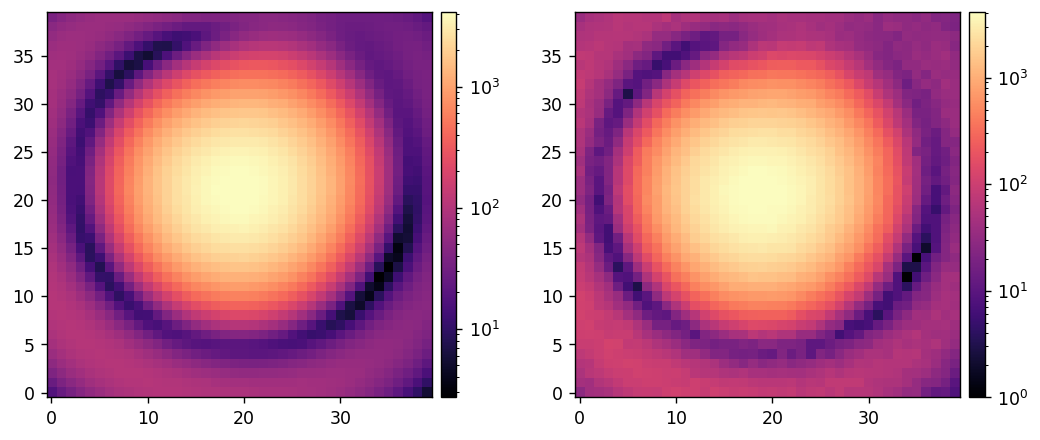

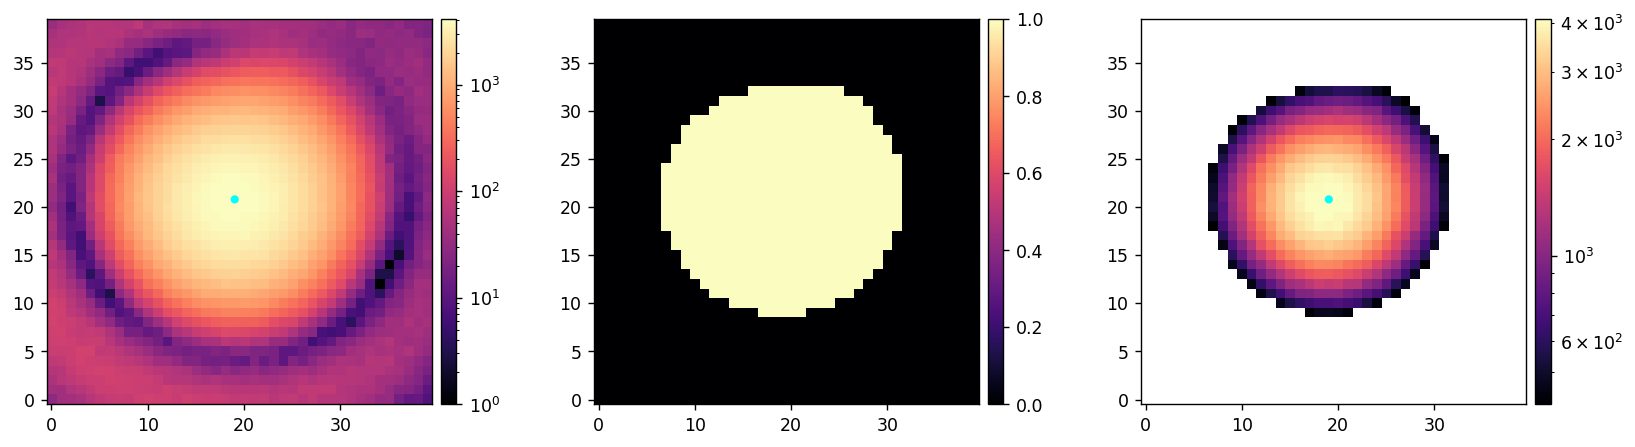

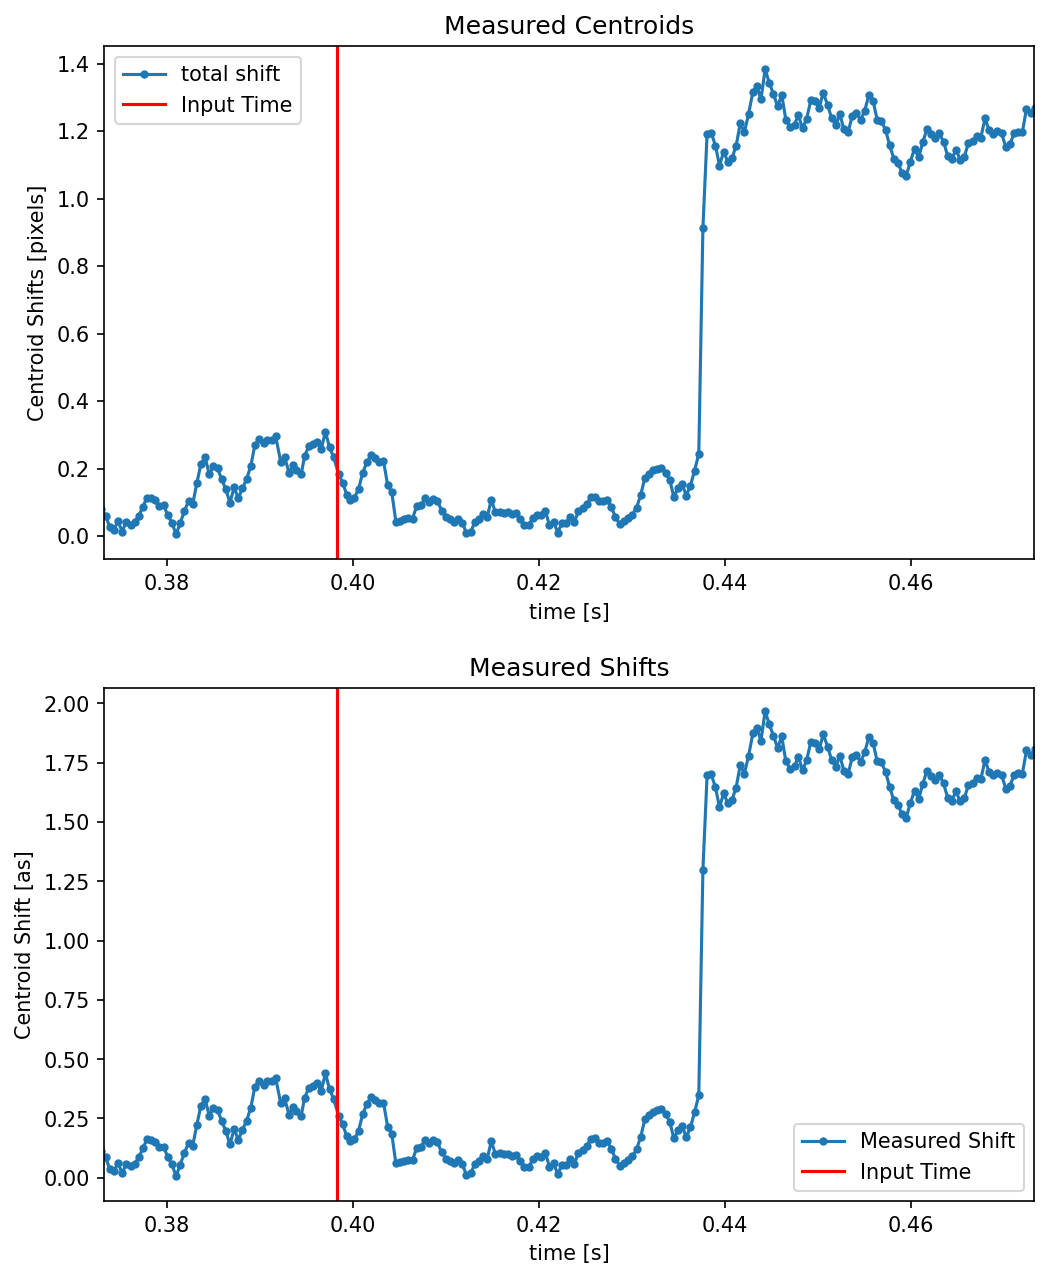

In [187]:
rel_thresh = 0.1

# ims = data['IMAGES']
ims = camfsm_data
N = ims.shape[0]
fps = cam.get_fps(client0)
times = camfsm_times
tmax = times.max()

mean_frame = np.mean(ims, axis=0)
utils.imshow([mean_frame, ims[0]], norms=[LogNorm(), LogNorm()])

shift_pix = []
cen_0 = utils.centroid(ims[0].astype(float), thresh=rel_thresh*ims[0].max(), plot=True)
for i in range(N):
    cen = utils.centroid(ims[i].astype(float), thresh=rel_thresh*ims[i].max(), plot=0)
    shift = cen - cen_0
    shift_pix.append(shift)
shift_pix = np.array(shift_pix)

total_shift = np.sqrt( np.sum( np.square(shift_pix), axis=1) )

shift_as = shift_pix * pxscl_lamD * as_per_lamD # pixels * (lamD/pixel) * (as/lamD)
shift_as = np.sqrt( np.sum( np.square(shift_as), axis=1) )

fig, axs = plt.subplots(2, 1, figsize=(8,10), dpi=150)

xlims = [0,tmax]

width = 0.1
xlims = [dm1_times[0]-width/4, dm1_times[0]+width*3/4]

marker = 'o'
ms = 3.0

ax = axs[0]
ax.plot(times, total_shift, marker=marker, markersize=ms, label='total shift')
ax.axvline(x=dm1_times[0], color='red', linestyle='-', label='Input Time')
ax.set_title(f'Measured Centroids')
ax.set_ylabel('Centroid Shifts [pixels]')
ax.set_xlabel('time [s]')
ax.set_xlim(xlims)
# ax.xlim([0, 1])
ax.legend()

ax = axs[1]
ax.plot(times, shift_as, marker=marker, markersize=ms, label='Measured Shift')
ax.axvline(x=dm1_times[0], color='red', linestyle='-', label='Input Time')
ax.set_title(f'Measured Shifts')
ax.set_ylabel('Centroid Shift [as]')
ax.set_xlabel('time [s]')
ax.set_xlim(xlims)
# ax.xlim([0, 1])
ax.legend()

fig.subplots_adjust(
    hspace=0.25,
)
plt.close()
display(fig)

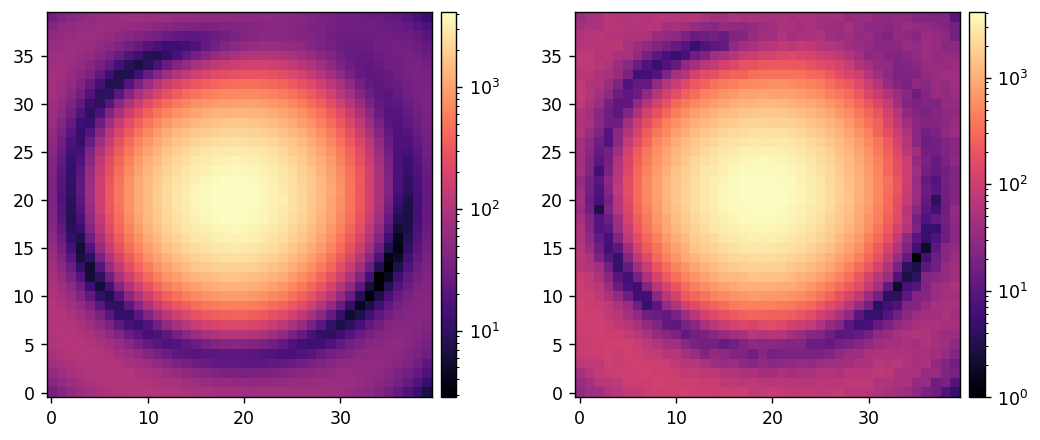

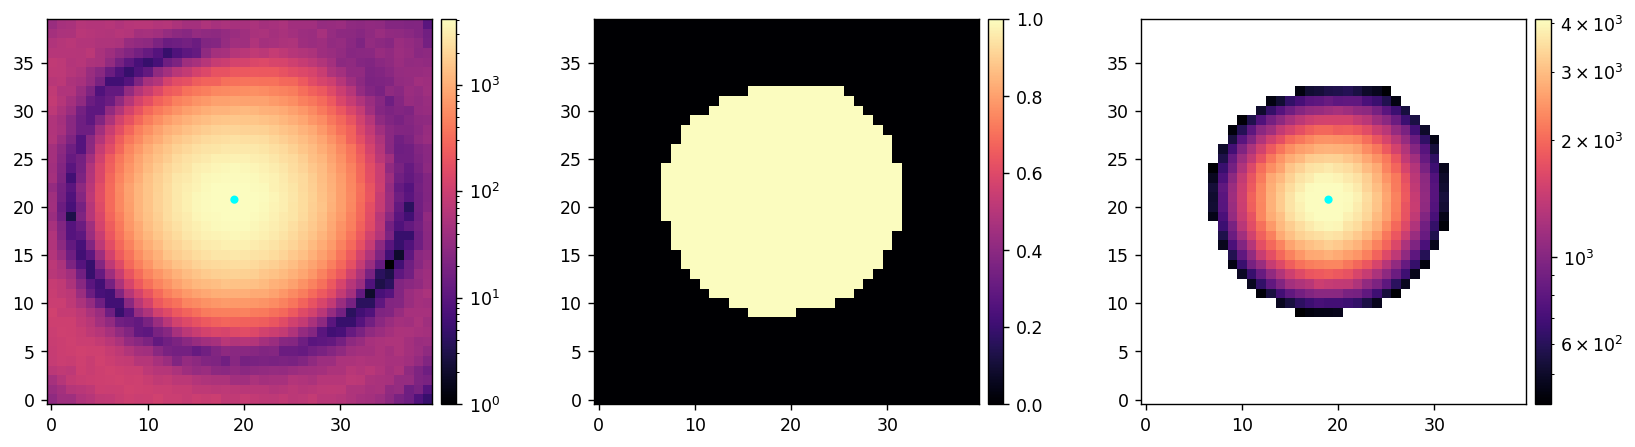

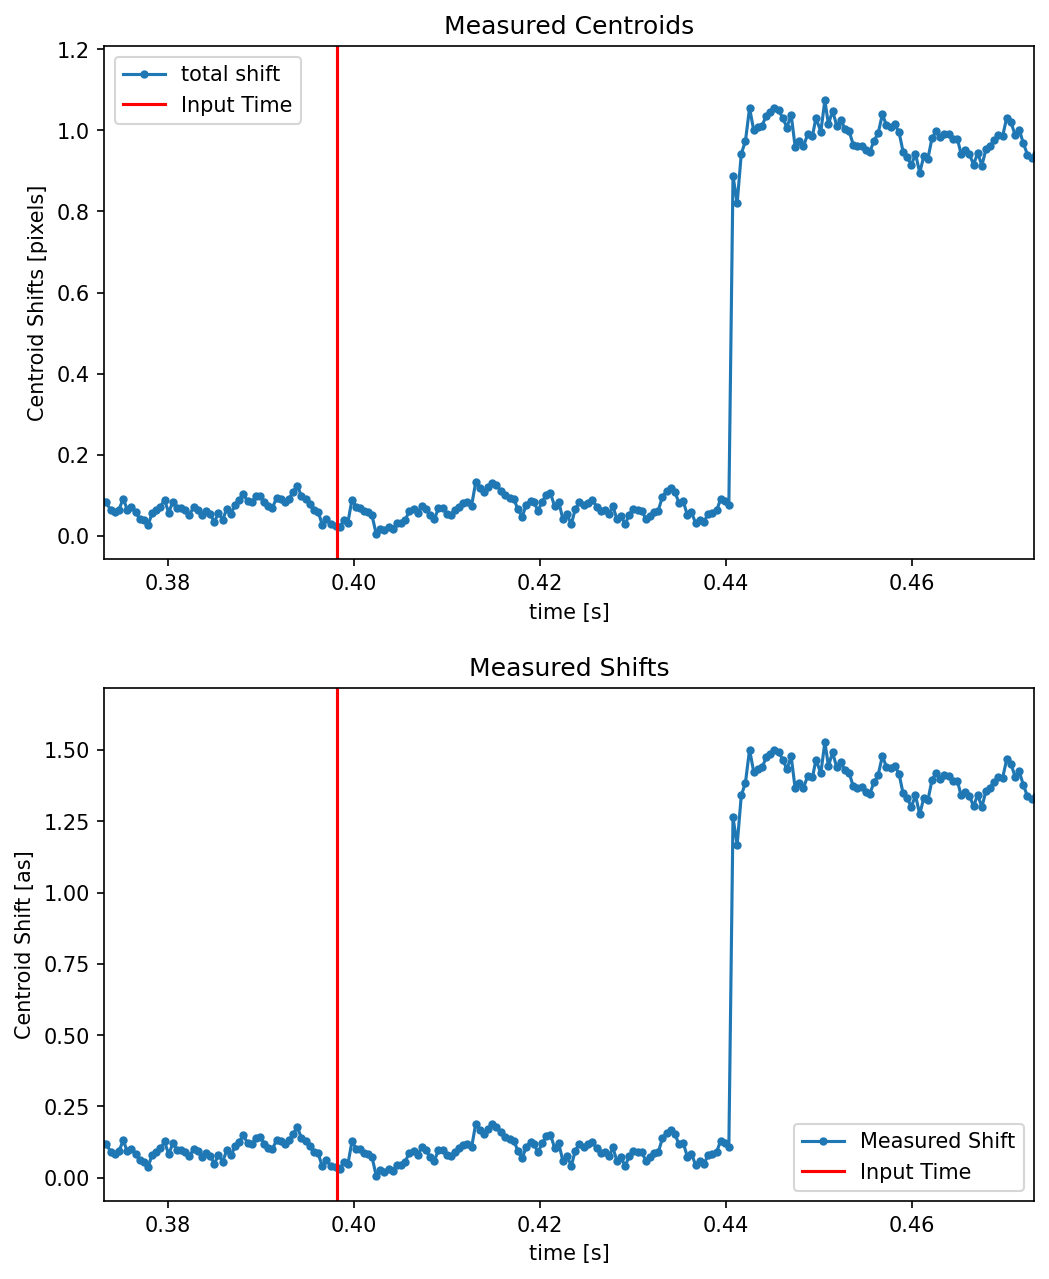

In [169]:
rel_thresh = 0.1

# ims = data['IMAGES']
ims = camfsm_data
N = ims.shape[0]
fps = cam.get_fps(client0)
times = camfsm_times
tmax = times.max()

mean_frame = np.mean(ims, axis=0)
utils.imshow([mean_frame, ims[0]], norms=[LogNorm(), LogNorm()])

shift_pix = []
cen_0 = utils.centroid(ims[0].astype(float), thresh=rel_thresh*ims[0].max(), plot=True)
for i in range(N):
    cen = utils.centroid(ims[i].astype(float), thresh=rel_thresh*ims[i].max(), plot=0)
    shift = cen - cen_0
    shift_pix.append(shift)
shift_pix = np.array(shift_pix)

total_shift = np.sqrt( np.sum( np.square(shift_pix), axis=1) )

shift_as = shift_pix * pxscl_lamD * as_per_lamD # pixels * (lamD/pixel) * (as/lamD)
shift_as = np.sqrt( np.sum( np.square(shift_as), axis=1) )

fig, axs = plt.subplots(2, 1, figsize=(8,10), dpi=150)

xlims = [0,tmax]

width = 0.1
xlims = [dm1_times[0]-width/4, dm1_times[0]+width*3/4]

marker = 'o'
ms = 3.0

ax = axs[0]
ax.plot(times, total_shift, marker=marker, markersize=ms, label='total shift')
ax.axvline(x=dm1_times[0], color='red', linestyle='-', label='Input Time')
ax.set_title(f'Measured Centroids')
ax.set_ylabel('Centroid Shifts [pixels]')
ax.set_xlabel('time [s]')
ax.set_xlim(xlims)
# ax.xlim([0, 1])
ax.legend()

ax = axs[1]
ax.plot(times, shift_as, marker=marker, markersize=ms, label='Measured Shift')
ax.axvline(x=dm1_times[0], color='red', linestyle='-', label='Input Time')
ax.set_title(f'Measured Shifts')
ax.set_ylabel('Centroid Shift [as]')
ax.set_xlabel('time [s]')
ax.set_xlim(xlims)
# ax.xlim([0, 1])
ax.legend()

fig.subplots_adjust(
    hspace=0.25,
)
plt.close()
display(fig)

In [208]:
1/0.04

25.0

# Power Off

In [210]:
cam.set_roi(xc+shift[0], yc+shift[1], 256, client0)

In [211]:
DM0_STREAM.write(zeros)
DM1_STREAM.write(zeros)

In [212]:
fsm_utils.power_fsm('Off', client0)